In [1]:
using StatsBase, Distributions, SharedArrays, Random

# Input parameters
# ------------------------------------------------

const BURN_IN_GEN_N = 0
const TOTAL_GEN_N = 120

# Max coordinates of the population bounding space
# (population = disk)
const X_MAX_BURN_IN = 5
const X_MAX = 250
const Y_MAX = 10

 # (population reaches space bounds)
const X_START = X_MAX_BURN_IN
const Y_START = Y_MAX
# (population starts out twice smaller)
#const X_START = trunc(X_MAX/2)
#const Y_START = trunc(Y_MAX/2)

# Dimensions of the whole space
const X_DIM = X_MAX
const Y_DIM = Y_MAX

# Population parameters
#const INIT_PERSON_N = 30
const DEMES_FULL_AT_START = 5
const K_CAPACITY = 100
const R_PROLIF_RATE = 2
const r_LOG_PROLIF_RATE = log(2)

# Gene parameters
const LOCI_N = 20
const MUT_RATE = 0.05
const M_MIG_RATE = 0.05
const MUT_DELETER_RATE = 0.9
const S_SELECT_COEF = 0.005
const possible_dirs = [[-1,0],[0,-1],[0,1],[1,0]] #[[-1,-1],[-1,0],[-1,1],[0,-1],[0,1],[1,-1],[1,0],[1,1]]

# Main program
# ------------------------------------------------

x_range = 1:Int(X_START)
y_range = 1:Int(Y_START)
possible_init_coords = [collect(x) for x in Iterators.product(x_range, y_range)]
init_coords = sample(possible_init_coords,DEMES_FULL_AT_START;replace=false)

world = Array{Array{Array{Float32}}}(undef,X_DIM,Y_DIM)

for coord in init_coords
    if !isassigned(world,coord...)
        world[coord...] = []
    end
    for i in 1:K_CAPACITY
        push!(world[coord...],ones(LOCI_N*2))
    end
end
println()

a = SharedArray{Float32}(X_MAX, Y_MAX, TOTAL_GEN_N, 1)
a = SharedArray{Float32}(X_MAX, Y_MAX, TOTAL_GEN_N, 1)

@inbounds function multi_fitn_in_person(person)
    return prod(person)
end

@inbounds function max_fitn(persons_at_pos)
    return maximum(multi_fitn_in_person.(persons_at_pos))
end

@inbounds function mean_fitn(persons_at_pos)
    return mean(multi_fitn_in_person.(persons_at_pos))
end

@inbounds function mutate(person)
    get_mutation_random = rand(Poisson(MUT_RATE))
    @fastmath @inbounds for _ in 1:get_mutation_random
        pos_alter = sample(1:LOCI_N)
        if rand() < MUT_DELETER_RATE
            person[pos_alter] *= 1 - S_SELECT_COEF
        else
            person[pos_alter] *= 1 + S_SELECT_COEF
        end
    end
end

@inbounds function recombine(person)
    for i in 1:LOCI_N
        lr = rand(1:2)
        person[i] = lr==1 ? person[i] : person[i+LOCI_N]
    end
end

@inbounds function mate_cond(mom_fit,dad_fit,max_fitness)
    return (mom_fit > rand()*max_fitness) & (dad_fit > rand()*max_fitness)
end

@inbounds function mate(person1,person2)
    new_loci = vcat(person1[1:LOCI_N],person2[1:LOCI_N])
    return new_loci
end

@inbounds function build_next_gen(wld,x_max_migrate)
    # Determine the number of offspring for each deme
    next_gen_pops = zeros(Int16,X_DIM,Y_DIM)
    next_gen_posits = []
    
    fill!(next_gen_pops,-1)
    for k in Iterators.product([1:n for n in (X_MAX,Y_MAX)]...)
        if isassigned(world,k...) && length(world[k...])>0
            n_ppl_at_deme = length(world[k...])
            expected_offspring = n_ppl_at_deme * (R_PROLIF_RATE/(1 + (n_ppl_at_deme*(R_PROLIF_RATE-1))/K_CAPACITY))
            #println("A",n_ppl_at_deme)
            next_gen_pops[k...] =  rand(Poisson(expected_offspring))
            if next_gen_pops[k...]>0
                push!(next_gen_posits,[k...])
            end
            #println("B",next_gen_pops[k...],next_gen_posits)
        end
    end
    

    # Define the world (habitat)
    wld_next = Array{Array{Array{Float32}}}(undef,X_DIM,Y_DIM)
    
    all_birth_count = 0

    # Main generation cycle (algorithm)
    mean_fitn_wld = Array{Float32}(undef,X_DIM,Y_DIM)
    fill!(mean_fitn_wld,-1)
    pops_wld = zeros(Int32,X_DIM,Y_DIM)

    for deme in next_gen_posits
        curr_persons_at_pos = wld[deme...]
        mean_fitn_wld[deme...] = mean_fitn(curr_persons_at_pos)
        max_fitness =  max_fitn(curr_persons_at_pos)
        

        next_generation_size = next_gen_pops[deme...]
        
        if next_generation_size > 0
            birth_count = 0
            
            while birth_count < next_generation_size
                
                mom = sample(curr_persons_at_pos) #[rand(1:end)]
                dad = sample(curr_persons_at_pos) #[rand(1:end)]
                
                mom_fit = multi_fitn_in_person(mom)
                dad_fit = multi_fitn_in_person(dad)

                if mate_cond(mom_fit,dad_fit,max_fitness)
                    
                    gamete_mom = copy(mom) # technically a person, but we'll only use the first half of loci in the mate function
                    gamete_dad = copy(dad) # technically a person, but we'll only use the first half of loci in the mate function
                    recombine(gamete_mom)
                    recombine(gamete_dad)
                    mutate(gamete_mom)
                    mutate(gamete_dad)
                    
                    mate_result = mate(gamete_mom,gamete_dad)
                    
                    #mutate(mate_result)

                    move_x = 0
                    move_y = 0
                    if rand()<M_MIG_RATE
                        dir = copy(sample(possible_dirs))
                        
                        move_x = copy(dir[1])
                        move_y = copy(dir[2])
                        if deme[1]+move_x > x_max_migrate || deme[1]+move_x < 1
                            move_x = 0
                            #move_x = -move_x
                        end
                        if deme[2]+move_y > Y_MAX || deme[2]+move_y < 1
                            move_y = 0
                            #move_y = -move_y
                        end
                    end

                    if !isassigned(wld_next,deme[1]+move_x,deme[2]+move_y)
                        wld_next[deme[1]+move_x,deme[2]+move_y] = []
                    end
                    push!(wld_next[deme[1]+move_x,deme[2]+move_y],mate_result)
                    #println([move_x,move_y],deme)
                    birth_count += 1
                    all_birth_count += 1
                end
            end
            pops_wld[deme...] = birth_count
        end
    end
    return wld_next,mean_fitn_wld,pops_wld
end

# Iterate the main cycle and save the output
# ------------------------------------------------

meanf_world = Array{Float32}(undef,X_DIM,Y_DIM,0)
pops_world = Array{Float32}(undef,X_DIM,Y_DIM,0)

@inbounds for _ in 1:BURN_IN_GEN_N
    global world,meanf,pops = build_next_gen(world,X_MAX_BURN_IN)
    global meanf_world = cat(meanf_world,meanf, dims=3)
    global pops_world = cat(pops_world,pops, dims=3)
end

@inbounds for j in (BURN_IN_GEN_N+1):TOTAL_GEN_N
    #println(j)
    
    global world,meanf,pops = build_next_gen(world,X_MAX)
    #println("B"*string(rand()))
    global meanf_world = cat(meanf_world,meanf, dims=3)
    global pops_world = cat(pops_world,pops, dims=3)
end

In [2]:
using Serialization
serialize("data/heh/2d_test_10-meanf.dat",meanf_world)

1200000

┌ Info: Saved animation to d:\Coding\RESK\study\animations\3-1.gif
└ @ Plots C:\Users\Hartree\.julia\packages\Plots\ju9dp\src\animation.jl:156


Plots.AnimatedGif("d:\\Coding\\RESK\\study\\animations\\3-1.gif")
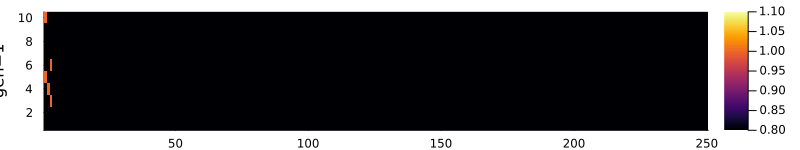

In [12]:
using Plots
slow_down = 1
gen_start = 1
gen_end = 60

anim = @animate for i ∈ gen_start:(gen_end-1)
    heatmap(meanf_world[:,:,i]',ylabel="gen=$i",size=(800,150),clims=(0.8,1.1))
end
gif(anim,"animations/3-1.gif")

In [9]:
f(x) = [i^23/5455 for i in 1:x]
a, timte = @timed f(33333)
println(timte)

0.0002342


In [72]:
MIGR_PROBS = [
    Dict(["ort" => (1, 0)]), # 1D
    Dict(["ort" => (1, 0), "all" => (1 / 2, 1 / 2), "buffon1" => (2 / pi, 1 / pi), "buffon2" => (4 / 3 / pi, 1 / 3 / pi), "buffon3" => (0.4244132, 0.21221), "diag1/2" => (2 / 3, 1 / 3)]), # 2D. To add "hex"!
    Dict(["ort" => (1, 0), "all" => (1 / 2, 1 / 2), "buffon1" => (2 / pi, 1 / pi), "buffon2" => (4 / 3 / pi, 1 / 3 / pi), "buffon3" => (0.4244132, 0.21221), "diag1/2" => (2 / 3, 1 / 3)]) # 3D. To add "hex"! To confirm Buffon for 3d!
]
MIGR_DIRS_ORT = [
    [[1], [-1]], # 1D
    [[-1, 0], [0, -1], [0, 1], [1, 0]], # 2D
    [[-1, 0, 0], [1, 0, 0], [0, 1, 0], [0, -1, 0], [0, 0, -1], [0, 0, 1]] # 3D
]

meow1 = []
Random.seed!(3333)
for _ in 1:80000
    
    migr_res = 0.5
    p_lat, p_diag = MIGR_PROBS[1]["ort"]

    if rand() < M_MIG_RATE && migr_res < p_lat + p_diag
        if migr_res < p_lat
            dir = copy(sample(MIGR_DIRS_ORT[1]))
        elseif migr_res < p_lat + p_diag
            dir = copy(sample(MIGR_DIRS_DIAG[1]))
        end
        meow1 = vcat(meow1,dir)
    end
end
meow2 = []
Random.seed!(3333)
for _ in 1:80000
    if rand() < M_MIG_RATE
        move_x = sample([1,-1])
        meow2 = vcat(meow2,move_x)
    end
end

In [74]:
meow2

3873-element Vector{Any}:
  1
  1
 -1
 -1
  1
 -1
  1
 -1
 -1
  1
  ⋮
  1
 -1
  1
 -1
 -1
  1
 -1
 -1
  1